## 1 

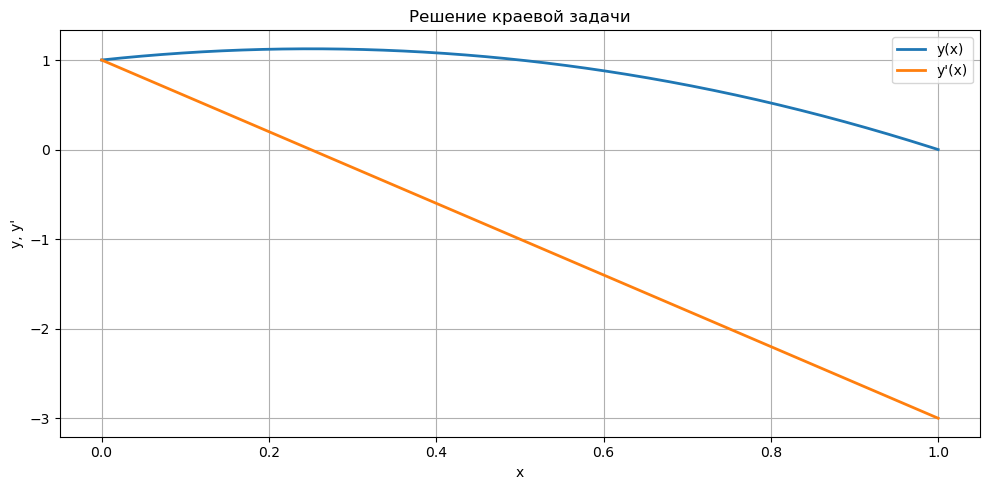

Подобранное значение y(0): 0.999887


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar

def ode_system(x, Y):
    y1, y2 = Y
    dy1dx = y2
    dy2dx = - (1 - 4 * x) * y2 - 8 * y1 + 5
    return [dy1dx, dy2dx]

def boundary_residual(y0_guess):
    sol = solve_ivp(ode_system, [0, 1], [y0_guess, y0_guess], t_eval=[1])
    y1_at_1 = sol.y[0][-1]
    return y1_at_1  # хотим y(1) = 0

res = root_scalar(boundary_residual, bracket=[-10, 10], method='brentq')
y0_correct = res.root

x_vals = np.linspace(0, 1, 500)
sol = solve_ivp(ode_system, [0, 1], [y0_correct, y0_correct], t_eval=x_vals)
y = sol.y[0]
yp = sol.y[1]

plt.figure(figsize=(10, 5))
plt.plot(x_vals, y, label='y(x)', lw=2)
plt.plot(x_vals, yp, label="y'(x)", lw=2)
plt.title('Решение краевой задачи')
plt.xlabel('x')
plt.ylabel('y, y\'')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f'Подобранное значение y(0): {y0_correct:.6f}')


## 2

In [14]:
import numpy as np

def derivs(x, A, B):
    return -1 - A*A, x*np.cos(x) - A*B

N = 20000
h = (np.pi/2) / N
A, B, x = 3.0, 2.0, 0.0

for _ in range(N):
    k1A, k1B = derivs(x,           A,            B)
    k2A, k2B = derivs(x + 0.5*h, A + 0.5*h*k1A, B + 0.5*h*k1B)
    k3A, k3B = derivs(x + 0.5*h, A + 0.5*h*k2A, B + 0.5*h*k2B)
    k4A, k4B = derivs(x + h,     A +   h*k3A,   B +   h*k3B)
    A += h*(k1A + 2*k2A + 2*k3A + k4A)/6
    B += h*(k1B + 2*k2B + 2*k3B + k4B)/6
    x += h

y_end  = (2 - B) / (A + 5)
yp_end = A*y_end + B

print(f"y(π/2)  = {y_end:.6f}")
print(f"y'(π/2) = {yp_end:.6f}")


y(π/2)  = 0.175361
y'(π/2) = 1.123196


## 3

In [4]:
import numpy as np

def n_func(x):
    """Функция n(x) = 1 + exp(-3(x-5)^2)."""
    return 1.0 + np.exp(-3.0 * (x - 5.0)**2)

def rk4_step(y, x, h):
    """
    Один шаг метода Рунге–Кутты 4-го порядка для системы
      y = [φ, φ', p, p'],
    где p = ∂φ/∂s,  p' = ∂φ'/∂s.
    """
    def f(y, x):
        φ, φp, p, pp = y
        return np.array([
            φp,
            np.exp(φ) - n_func(x),
            pp,
            np.exp(φ) * p
        ])
    k1 = f(y,     x)
    k2 = f(y+0.5*h*k1, x+0.5*h)
    k3 = f(y+0.5*h*k2, x+0.5*h)
    k4 = f(y+    h*k3, x+    h)
    return y + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def shoot_and_deriv(s, N=5000):
    """
    Интегрирует от x=0 до x=10 систему для φ и её чувствительности к начальному наклону s.
    Возвращает G(s)=φ(10) и G'(s)=∂φ(10)/∂s = p(10).
    """
    x0, x1 = 0.0, 10.0
    h = (x1 - x0) / N
    y = np.array([0.0, s, 0.0, 1.0])  # [φ(0)=0, φ'(0)=s, p(0)=0, p'(0)=1]
    x = x0
    for _ in range(N):
        y = rk4_step(y, x, h)
        x += h
    φ_end, _, p_end, _ = y
    return φ_end, p_end

def find_initial_s(
    s0=0.0,
    tol=1e-10,
    max_iter=15,
    N=5000
):
    """
    Ньютонианская стрельба с backtracking-line-search:
      ищем s: φ(10;s)=0
    """
    s = s0
    for k in range(1, max_iter+1):
        G, Gp = shoot_and_deriv(s, N=N)
        delta = -G / Gp

        # backtracking на α: ищем в {1, 1/2, 1/4, ...}
        α = 1.0
        while α > 1e-4:
            s_try = s + α * delta
            G_try, _ = shoot_and_deriv(s_try, N=N)
            # условие достаточного уменьшения: |G_try| < |G|
            if np.isfinite(G_try) and abs(G_try) < abs(G):
                break
            α *= 0.5

        s = s_try
        print(f"iter {k:2d}: α={α:.3f}, Δs={α*delta:.2e}, φ(10)={G_try:.2e}")

        if abs(α * delta) < tol:
            print(f"\nСошлось за {k} итераций Ньютона с точностью {tol}.")
            return s

    raise RuntimeError("Не удалось сойтись за отведённое число итераций")

if __name__ == "__main__":
    # Запускаем подбор начального наклона
    s_found = find_initial_s(
        s0=0.0,      # стартовое приближение для φ'(0)
        tol=1e-10,   # требуемая точность по Δs
        max_iter=15, # макс. число итераций Ньютона
        N=7000       # число шагов RK4 на [0,10]
    )
    print(f"\nНайденное значение φ'(0) = {s_found:.12f}")


/var/folders/9g/q_qrtv595_z_sv27l9yqktvh0000gn/T/ipykernel_7163/4190620771.py:17: RuntimeWarning: overflow encountered in exp
  np.exp(φ) - n_func(x),
/var/folders/9g/q_qrtv595_z_sv27l9yqktvh0000gn/T/ipykernel_7163/4190620771.py:19: RuntimeWarning: overflow encountered in exp
  np.exp(φ) * p


iter  1: α=0.250, Δs=4.39e-03, φ(10)=-9.33e+00
iter  2: α=0.250, Δs=1.18e-03, φ(10)=-6.29e+00
iter  3: α=0.500, Δs=8.97e-04, φ(10)=-7.42e-01
iter  4: α=1.000, Δs=5.30e-05, φ(10)=1.04e-01
iter  5: α=1.000, Δs=-5.66e-06, φ(10)=1.75e-03
iter  6: α=1.000, Δs=-9.88e-08, φ(10)=5.08e-07
iter  7: α=1.000, Δs=-2.86e-11, φ(10)=3.91e-13

Сошлось за 7 итераций Ньютона с точностью 1e-10.

Найденное значение φ'(0) = 0.006517589822


## 4

In [5]:
import numpy as np
from scipy.linalg import solve

def n_func(x):
    """n(x) = 1 + exp(-3*(x-5)^2)"""
    return 1.0 + np.exp(-3.0*(x - 5.0)**2)

def build_F_J(phi, x, h):
    """
    Для текущего вектора φ (размер M),
    строим невязку F и якобиан J размером M×M
    для уравнений
      F_i = (φ_{i-1} - 2φ_i + φ_{i+1})/h^2 - exp(φ_i) + n(x_i).
    Граничные φ₀=φ_{M+1}=0 вычлили заранее.
    """
    M = len(phi)
    F = np.empty(M)
    diag = np.empty(M)
    off = 1.0/h**2

    # точки i=1…M, соответствуют x[1..M]
    for i in range(M):
        xm = phi[i-1] if i>0 else 0.0
        xp = phi[i+1] if i<M-1 else 0.0
        F[i] = (xm - 2.0*phi[i] + xp)/h**2 - np.exp(phi[i]) + n_func(x[i+1])
        # диагональный элемент J_{ii}
        diag[i] = -2.0/h**2 - np.exp(phi[i])

    # составляем разреженный трехдиагональный якобиан
    J = np.zeros((M,M))
    for i in range(M):
        J[i,i] = diag[i]
        if i>0:   J[i,i-1] = off
        if i<M-1: J[i,i+1] = off
    return F, J

def newton_bvp(M=200, tol=1e-10, max_iter=20):
    """
    Решаем φ''=exp(φ)-n(x), φ(0)=φ(10)=0
    на сетке из M внутренних узлов + 2 граничных.
    Возвращаем φ(все узлы), число итераций Ньютона.
    """
    # сетка, M+2 точек, h=шаг
    x = np.linspace(0,10,M+2)
    h = x[1]-x[0]

    # начальное приближение (линейно спадает к нулю)
    phi = np.zeros(M)  

    for k in range(1, max_iter+1):
        F, J = build_F_J(phi, x, h)
        # здесь ||δφ||∞ будет оцениваться по решению J·d = -F
        dphi = solve(J, -F)
        phi += dphi
        err = np.max(np.abs(dphi))
        print(f"Newton it {k:2d}: ||Δφ||∞ = {err:.2e}")
        if err < tol:
            # соберём полный вектор с границами
            phi_full = np.zeros(M+2)
            phi_full[1:-1] = phi
            return x, phi_full, k

    raise RuntimeError("Newton did not converge")

if __name__ == "__main__":
    xs, phis, its = newton_bvp(M=300, tol=1e-10)
    print(f"\nДостигнуто 10 значащих цифр за {its} итераций Ньютона.")
    # например, распечатаем φ в нескольких точках
    for xi, yi in zip(xs[::50], phis[::50]):
        print(f"x={xi:5.2f}, φ={yi:.6e}")


Newton it  1: ||Δφ||∞ = 3.80e-01
Newton it  2: ||Δφ||∞ = 3.28e-02
Newton it  3: ||Δφ||∞ = 3.43e-04
Newton it  4: ||Δφ||∞ = 3.83e-08
Newton it  5: ||Δφ||∞ = 1.30e-15

Достигнуто 10 значащих цифр за 5 итераций Ньютона.
x= 0.00, φ=0.000000e+00
x= 1.66, φ=1.656073e-02
x= 3.32, φ=9.141778e-02
x= 4.98, φ=3.466506e-01
x= 6.64, φ=9.456205e-02
x= 8.31, φ=1.716272e-02
x= 9.97, φ=2.165799e-04


## 5

In [7]:
import numpy as np

def x0(t): return (3 - t) / 6
def phi1(t): return t * (1 - t)
def phi2(t): return t * (1 - t) * (2*t - 1)
def dphi1(t): return 1 - 2*t
def dphi2(t): return (1 - 2*t)*(2*t - 1) + 2*t*(1 - t)
def x_exact(t): return 1 / (2 + t)

t = np.linspace(0, 1, 2001)
p1, p2 = phi1(t), phi2(t)
dp1, dp2 = dphi1(t), dphi2(t)
x0v = x0(t)
R = -2 * x0v**3

A11 = np.trapz(dp1*dp1 + 6*x0v**2*p1*p1, t)
A12 = np.trapz(dp1*dp2 + 6*x0v**2*p1*p2, t)
A22 = np.trapz(dp2*dp2 + 6*x0v**2*p2*p2, t)
L1  = np.trapz(R * p1, t)
L2  = np.trapz(R * p2, t)

a1_1 = L1 / A11
A = np.array([[A11, A12],
              [A12, A22]])
L = np.array([L1, L2])
a1_2, a2_2 = np.linalg.solve(A, L)

tf = np.linspace(0, 1, 1001)
x1 = x0(tf) + a1_1 * phi1(tf)
x2 = x0(tf) + a1_2 * phi1(tf) + a2_2 * phi2(tf)
ex = x_exact(tf)

err1 = np.max(np.abs(x1 - ex)) / np.max(np.abs(ex))
err2 = np.max(np.abs(x2 - ex)) / np.max(np.abs(ex))

print("Первое приближение (N=1):")
print(f"a1 = {a1_1:.6e}")
print(f"Относительная погрешность = {err1:.2e} ({err1*100:.2f}%)\n")
print("Второе приближение (N=2):")
print(f"a1 = {a1_2:.6e}, a2 = {a2_2:.6e}")
print(f"Относительная погрешность = {err2:.2e} ({err2*100:.2f}%)")


Первое приближение (N=1):
a1 = -6.704976e-02
Относительная погрешность = 2.79e-03 (0.28%)

Второе приближение (N=2):
a1 = -6.697678e-02, a2 = 1.354534e-02
Относительная погрешность = 2.84e-04 (0.03%)
